<a href="https://colab.research.google.com/github/HakanTole1/HotDogvsNotHotDog_CNN/blob/main/HotDogvsNotHotDog_ConvolutionalNeuralNetwork(CNN)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Hot Dog or Not Hot Dog – Convolutional Neural Network Course for Beginners- FreeCodeCamp, Kylie Ying
# https://www.youtube.com/watch?v=nVhau51w6dM&t=74s

In [ ]:
!pip install --upgrade protobuf tensorflow-metadata tensorflow-datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 9.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.35.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.


In [ ]:
# For fast math operations and array/matrix manipulation
import numpy as np

# For handling data structures and tables
import pandas as pd

# For plotting graphs and displaying images
import matplotlib.pyplot as plt

# For picking random images or samples
import random

# The main deep learning framework to build the AI
import tensorflow as tf

# For building the CNN structure (layers and the model itself)
from tensorflow.keras import datasets, layers, models

# For easily downloading ready-made image datasets
import tensorflow_datasets as tfds

## Citation(Alıntı)


```
@inproceedings{bossard14,
  title = {Food-101 -- Mining Discriminative Components with Random Forests},
  author = {Bossard, Lukas and Guillaumin, Matthieu and Van Gool, Luc},
  booktitle = {European Conference on Computer Vision},
  year = {2014}
}
```



# Data
TensorFlow has the food 101 dataset already. We will use this! https://www.tensorflow.org/datasets/catalog/food101

Hot dog is label 55

In [ ]:
# Load the 'food101' dataset (contains 101 food categories, including hot dogs)
# shuffle_files=True: Randomizes the order of the dataset files
# as_supervised=True: Returns data as (image, label) pairs ready for training
# with_info=True: Also downloads the dataset metadata (like class names)
ds, ds_info = tfds.load('food101', shuffle_files=True, as_supervised=True, with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.PDZBKQ_2.0.0/food101-train.tfrecord-[0-9][0-9][0-9][0-9…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.PDZBKQ_2.0.0/food101-validation.tfrecord-[0-9][0-9][0-9…

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


In [ ]:
# Split the downloaded dataset into training and validation sets
# train_ds: The data our model will use to learn (study)
# valid_ds: The unseen data used to evaluate the model's performance (test)
train_ds, valid_ds = ds["train"], ds["validation"]

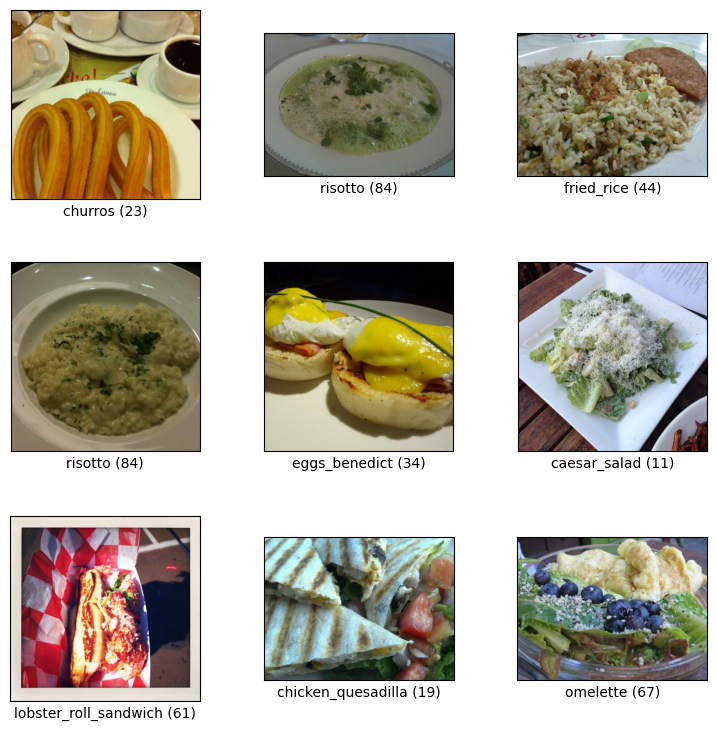

In [ ]:
# Display a grid of sample images and their labels from the training dataset
# This helps us visually verify what the food images look like
fig = tfds.show_examples(train_ds, ds_info)

In [ ]:
# Set the target image size (128x128 pixels) so all images have the same dimensions
MAX_SIDE_LEN = 128

# The label index for 'hot_dog' in the Food-101 dataset
HOT_DOG_CLASS = 55

# Preprocess the training data
# .map(): Works like an assembly line. It applies a function to every single item in the dataset automatically.
# lambda: A quick, one-line, anonymous function that acts as the "worker" on this assembly line.
# Together: They take each (image, label) pair, resize the image, and update the label to 1 (hot dog) or 0 (not hot dog).
train_ds = train_ds.map(
    lambda image, label: ( #we have image and label in each dataset, then get a new tuple , () ,
        # 1. Resize images to 128x128 and convert pixel values to integers
        tf.cast(tf.image.resize(image, [MAX_SIDE_LEN, MAX_SIDE_LEN]), dtype=tf.int32),
        # 2. Binary classification: Return 1 if it's a hot dog (55), 0 if it's anything else
        tf.cast(label == HOT_DOG_CLASS, dtype=tf.int32)
    )
)

# Apply the exact same preprocessing steps to the validation data
valid_ds = valid_ds.map(
    lambda image, label: (
        tf.cast(tf.image.resize(image, [MAX_SIDE_LEN, MAX_SIDE_LEN]), dtype=tf.int32),
        tf.cast(label == HOT_DOG_CLASS, dtype=tf.int32)
    )
)

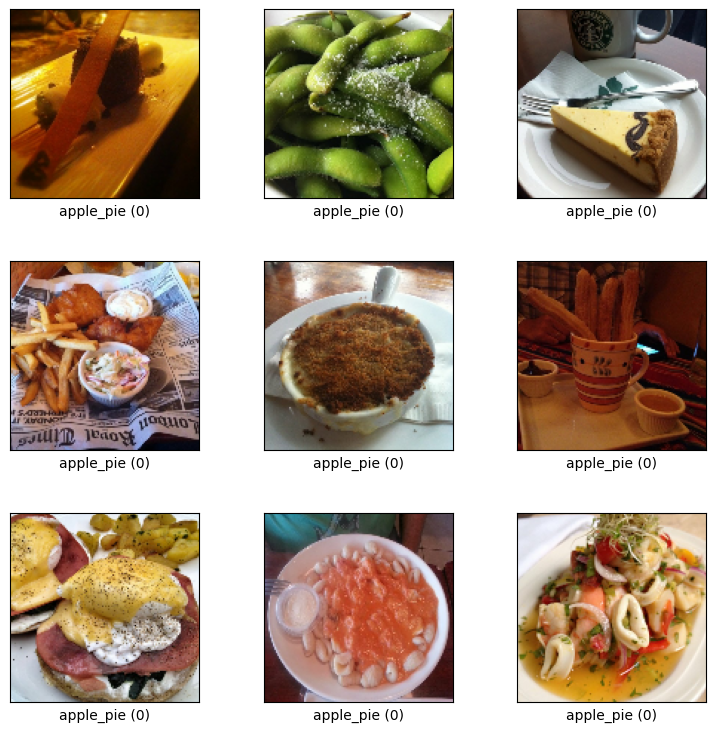

In [ ]:
# Display a grid of sample images with their newly updated labels (1 for Hotdog, 0 for Not Hotdog)
# This allows us to visually verify that our resizing and labeling process worked correctly
fig = tfds.show_examples(train_ds, ds_info)

In [ ]:
# Set the expected number of hot dog images in the training and validation sets
# (Food-101 has exactly 750 training and 250 validation images per class)
train_hd_size, valid_hd_size = 750, 250


#Label 0(not hotdog) has a hundred class 100*750=75.000

# Extract ONLY the hot dog images (label == 1).
# .repeat(3): Since there is only 1 hot dog class but 100 "not hot dog" classes,
# the data is highly unbalanced. We repeat the hot dog images 3 times to help balance the training.
#Label 1(hotdog) has one class with 750 train, 250 validation. 750*3=2.250 hotdog
train_hotdogs = train_ds.filter(lambda _, label: label == 1).repeat(3)

# Extract ONLY the "not hot dog" images (label == 0).
# We use '_' for the image variable in lambda because we only care about the label for filtering.
train_nothotdogs = train_ds.filter(lambda _, label: label == 0)

In [ ]:
# Apply the exact same filtering and balancing logic to the validation dataset (valid_ds)

# Extract validation hot dog images and repeat them 3 times to maintain a balanced test set
valid_hotdogs = valid_ds.filter(lambda _, label: label == 1).repeat(3)

# Extract validation "not hot dog" images
valid_nothotdogs = valid_ds.filter(lambda _, label: label == 0)

In [ ]:
valid_hotdogs

<_RepeatDataset element_spec=(TensorSpec(shape=(128, 128, 3), dtype=tf.int32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>

In [ ]:
# The number of images the AI will look at simultaneously before updating its weights
batch_size = 16

# THE SOLUTION TO CLASS IMBALANCE:
# Mix hotdogs and not-hotdogs together with a strict 50/50 ratio (weights=[0.5, 0.5]).
# stop_on_empty_dataset=True: Stops grabbing data when the smaller dataset (hotdogs) runs out.
train_ds = tf.data.Dataset.sample_from_datasets([train_hotdogs, train_nothotdogs], weights=[0.5, 0.5], stop_on_empty_dataset=True)

# OPTIMIZING THE DATA PIPELINE FOR SPEED:
# .cache(): Saves the processed images in memory so we don't do the math again next epoch.
# .batch(): Groups the data into batches of 16.
# .prefetch(): Prepares the next batch in the background while the GPU is training the current one.
train_ds = train_ds.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Apply the exact same 50/50 balancing and speed optimizations to the validation dataset
valid_ds = tf.data.Dataset.sample_from_datasets([valid_hotdogs, valid_nothotdogs], weights=[0.5, 0.5], stop_on_empty_dataset=True)
valid_ds = valid_ds.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [ ]:
# .take(3): Grab only the first 3 batches from the dataset to inspect them.
# Remember, each batch contains 16 images and 16 labels.
for image, label in train_ds.take(3):

  # image[0]: First image in the batch
  # image[0][0]: First row of pixels in that image
  # image[0][0][0]: The very first pixel (top-left corner).
  # This prints the RGB (Red, Green, Blue) color values of that single pixel.
  print(image[0][0][0])

  # Prints the array of 16 labels for this current batch (will be a mix of 0s and 1s)
  print(label)

tf.Tensor([253 255 254], shape=(3,), dtype=int32)
tf.Tensor([1 0 1 0 0 0 0 0 1 0 0 1 1 0 1 1], shape=(16,), dtype=int32)
tf.Tensor([109  98  83], shape=(3,), dtype=int32)
tf.Tensor([0 1 1 0 1 0 0 1 1 0 0 0 1 0 0 1], shape=(16,), dtype=int32)
tf.Tensor([12  9 29], shape=(3,), dtype=int32)
tf.Tensor([0 1 0 0 1 1 1 0 1 0 1 1 0 0 0 0], shape=(16,), dtype=int32)


# Neural Network implementation

In [ ]:
# Create a data augmentation pipeline to artificially increase image diversity.
# This prevents the AI from just memorizing the training images (overfitting).
data_augmentation = tf.keras.Sequential([
  # Randomly mirror the image left-to-right (a mirrored hotdog is still a hotdog!)
  tf.keras.layers.RandomFlip('horizontal'),

  # Randomly tilt/rotate the image by up to 20% (around 72 degrees)
  tf.keras.layers.RandomRotation(0.2),
])

In [ ]:
# .take(1) grabs exactly ONE sample from the original raw training dataset.
# The dataset returns a tuple: (image, label).
for i, _ in ds["train"].take(1):

  # 'i' represents the image tensor.
  # '_' is a Python convention meaning "I don't care about the second value (the label) right now."
  # We save this single raw image into the 'image' variable to inspect or plot it.
  image = i


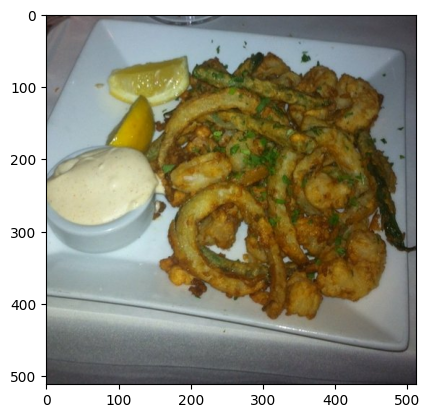

In [ ]:
# plt.imshow() (Image Show) takes the matrix of raw numbers (RGB values)
# and renders them as a visual image on your screen.
plt.imshow(image)

In [ ]:
# 1. tf.expand_dims(image, 0): Neural networks don't accept single images.
# They expect a "batch" (pack) of images. This wraps our single image into a batch of size 1.
# (Height, Width, Channels) becomes (1, Height, Width, Channels).

# 2. tf.cast(..., tf.float32): Converts the whole numbers (integers) into decimals (floats).
image = tf.cast(tf.expand_dims(image, 0), tf.float32)

# 3. Normalization: Scales the pixel values from [0 - 255] down to [0.0 - 1.0].
image /= 255.0

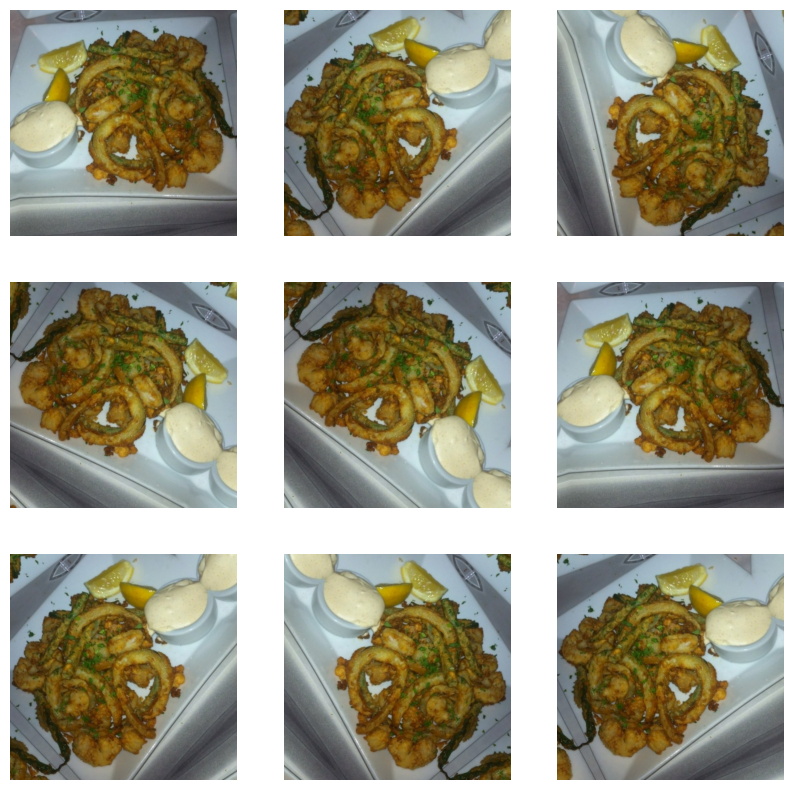

In [ ]:
# Create a 10x10 inch blank canvas for plotting the 9 images.
plt.figure(figsize=(10, 10))

# Loop 9 times (i from 0 to 8) to prepare each of the 9 images in the grid.
for i in range(9):
  # 1. GENERATE DIVERSITY
  # Use the previously created 'data_augmentation' pipeline.
  # Every time we call it on the same 'image', it applies random
  # transformations (flip/rotate) to create a UNIQUE version.
  augmented_image = data_augmentation(image)

  # 2. CREATE GRID SUBPLOT
  # Divide the canvas into a 3x3 grid (3 rows, 3 columns).
  # Use 'i+1' to set the active position, moving from left-to-right, top-to-bottom.
  ax = plt.subplot(3, 3, i+1)

  # 3. DISPLAY IMAGE
  # Render the new augmented view. (augmented_image[0] because the model
  # outputs a "batch" of images, even if it's a batch of one).
  plt.imshow(augmented_image[0])

  # 4. CLEANUP
  # Hide the X and Y axes (the rulers) so we just see the hotdog, not the coordinates.
  plt.axis("off")

#Start building CNN

In [ ]:
# Set a random seed so the results are reproducible (you get the same results every run)
random.seed(0)

# Initialize a Sequential model (a linear stack of layers)
model = models.Sequential()

# 1. PREPROCESSING LAYER
# Normalize pixel values from 0-255 down to 0-1. Neural networks learn much better with smaller numbers.
model.add(layers.Rescaling(1./255))

#Data Augmentation
model.add(data_augmentation)

# 2. FIRST CONVOLUTIONAL BLOCK (Finding basic patterns like edges and colors)
# Extracts 128 different features using 3x3 pixel grids. 'relu' keeps only positive values.
model.add(layers.Conv2D(128, (3, 3), activation='relu', input_shape=(MAX_SIDE_LEN, MAX_SIDE_LEN, 3)))
# Shrinks the image by half to reduce computational load and focus on the most important features.
model.add(layers.MaxPooling2D((2, 2)))
# Randomly turns off 25% of neurons during training to force the model not to memorize (prevents overfitting).
model.add(layers.Dropout(0.25))

# 3. SECOND CONVOLUTIONAL BLOCK (Finding complex patterns like shapes and textures)
# L2 Regularization acts like a "speed limit", preventing the model's weights from getting too large (another anti-overfitting trick).
model.add(layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))

# 4. THIRD CONVOLUTIONAL BLOCK (Finding very specific hotdog features like buns or sausages)
model.add(layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)))

# 5. FLATTENING
# Converts the 2D image matrices into a single 1D flat line of numbers so the Dense layer can read it.
model.add(layers.Flatten())

# 6. FULLY CONNECTED (DENSE) LAYER
# The "brain" that looks at all extracted features and tries to make sense of them.
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.25))

# 7. OUTPUT LAYER
# A single neuron. It will output a number that tells us if it's a hotdog (1) or not (0).
model.add(layers.Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# The learning rate determines how big of a step the AI takes when updating its knowledge.
# 0.0001 is a small, careful step size to ensure it doesn't overshoot the correct answer.
lr = 0.0001

# Compile configures the model for training by defining its strategy
model.compile(
    # The Optimizer (Adam): The engine that updates the model's weights based on the errors it makes.
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),

    # The Loss Function: Measures how wrong the model is.
    # BinaryCrossentropy is perfect for Yes/No (1/0) questions.
    # from_logits=True is CRUCIAL here because our final Dense(1) layer doesn't have a 'sigmoid' activation.
    # It outputs raw numbers (logits) instead of probabilities between 0 and 1.
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),

    # Metrics: How we will evaluate the model's success (Accuracy = percentage of correct guesses).
    metrics=['accuracy']
)

# Train the Model

In [ ]:
# An 'epoch' is one complete pass through the entire training dataset.
# epochs=50 means the AI will review the whole dataset 50 times to master it.
epochs = 50

# model.fit() starts the actual training process.
# We save the results into the 'history' variable so we can plot graphs later.
history = model.fit(
  train_ds,                  # The "study material" (hotdogs and not-hotdogs)
  validation_data=valid_ds,  # The "practice exam" given at the end of each epoch
  epochs=epochs,             # Number of times to study the material
  verbose=1                  # Shows a nice animated progress bar and stats while training
)

Epoch 1/50
    286/Unknown 342s 1s/step - accuracy: 0.5076 - loss: 1.7323

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


286/286 ━━━━━━━━━━━━━━━━━━━━ 454s 2s/step - accuracy: 0.5070 - loss: 1.5224 - val_accuracy: 0.5159 - val_loss: 1.1849
Epoch 2/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.5465 - loss: 1.0216 - val_accuracy: 0.6082 - val_loss: 0.9053
Epoch 3/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.5802 - loss: 0.8439 - val_accuracy: 0.6641 - val_loss: 0.8029
Epoch 4/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.5967 - loss: 0.7661 - val_accuracy: 0.6816 - val_loss: 0.7378
Epoch 5/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.6295 - loss: 0.7126 - val_accuracy: 0.6875 - val_loss: 0.7087
Epoch 6/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.6495 - loss: 0.6726 - val_accuracy: 0.7024 - val_loss: 0.6877
Epoch 7/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.6909 - loss: 0.6256 - val_accuracy: 0.6881 - val_loss: 0.6813
Epoch 8/50
286/286 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.7354 - loss: 0.5713 - val_accuracy: 0.68

In [ ]:
# Create a blank canvas for our images, setting the size to 10x10 inches
plt.figure(figsize=(10, 10))

# .take(1) grabs exactly ONE batch (16 images and 16 labels) from the validation set
# We don't need to see all thousands of images, just one batch is enough for a sneak peek!
for image_batch, label_batch in valid_ds.take(1):

  # Save these 16 images and their correct answers (labels) into variables
  # so we can draw them on the canvas in the next steps
  images = image_batch
  labels = label_batch

<Figure size 1000x1000 with 0 Axes>

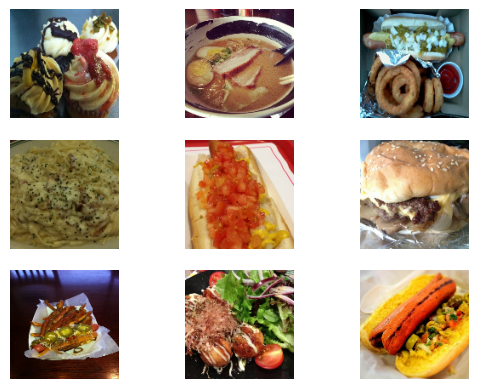

In [ ]:
# Loop 9 times (i goes from 0 to 8) to grab the first 9 images from our batch.
for i in range(9):

  # Create a 3x3 grid (3 rows, 3 columns).
  # 'i+1' tells matplotlib which specific cell to draw in (1st, 2nd, 3rd... up to 9th).
  ax = plt.subplot(3, 3, i+1)

  # Take the i-th image from our 'images' array and render it in the current cell.
  plt.imshow(images[i])

  # Hide the X and Y coordinates/rulers so we just see the clean photos.
  plt.axis("off")

In [ ]:
labels[:9]

<tf.Tensor: shape=(9,), dtype=int32, numpy=array([0, 0, 1, 0, 1, 0, 1, 0, 1], dtype=int32)>